<h1 style="color:#1B4332; border-bottom:3px solid #52B788; padding-bottom:8px;">🧠 Redes Neurais Convolucionais — Teoria & Prática com a LeNet-5</h1>

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #2D6A4F; margin:10px 0;">
<b>Curso:</b> NLW Rocketseat — Visão Computacional &nbsp;|&nbsp; <b>Aula 1</b><br>
Este notebook unifica os conceitos teóricos e a implementação prática de uma CNN clássica (<i>Convolutional Neural Network</i>) baseada na arquitetura <b>LeNet-5</b>, usando PyTorch.
</div>

<h2 style="color:#2D6A4F;">O que são Redes Neurais Convolucionais?</h2>

Redes Neurais Convolucionais são um tipo especializado de rede neural profunda criadas, predominantemente, para o **reconhecimento perceptivo de padrões** em dados com tipologia de grade, como é o caso das imagens (grades bidimensionais de pixels).

Devido à sua vasta capacidade de extrair e aprender **hierarquias de características espaciais** — partindo de traços rudimentares nas primeiras camadas, evoluindo para formas elaboradas (como rostos e objetos) em camadas subsequentes —, as CNNs são os alicerces mais vitais do campo da **Visão Computacional**.

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #2D6A4F; margin:10px 0;">
📌 <b>Nota sobre terminologia:</b> Neste material, a dimensão de profundidade do tensor (tradicionalmente referida como "canais") será referenciada como <b style="color:#40916C;">filtros</b>, reforçando o papel de cada slice como um detector de características.
</div>


<h2 style="color:#2D6A4F;">📖 Camadas Convolucionais e os Filtros</h2>

O núcleo computacional de uma CNN é a <b style="color:#40916C;">camada de convolução</b> (`nn.Conv2d` em PyTorch). 
Uma operação convolutiva consiste em uma **varredura** deslizando pequenas matrizes — comumente chamadas de *kernels* (ex. 5×5) — ao longo de toda a superfície da imagem fornecida.

<h3 style="color:#40916C;">Como funciona na LeNet-5?</h3>

* <b style="color:#40916C;">Primeira Camada (conv1)</b>: Recebe 1 **filtro** de entrada (escala de cinza) e produz 6 **filtros** de saída. Cada filtro extrai, de forma autônoma, uma característica gráfica específica (bordas, curvas, etc.).
* <b style="color:#40916C;">Segunda Camada (conv2)</b>: Recebe os 6 **filtros** da camada anterior e, combinando-os, gera 16 novos **filtros** — representações cada vez mais abstratas e poderosas.

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #2D6A4F; margin:10px 0;">
💡 Os pesos dos kernels são <b>inicializados aleatoriamente</b> e depois refinados durante o treinamento. Por isso, antes de treinar, os filtros parecem "ruído".
</div>


<h2 style="color:#2D6A4F;">🏗️ Definindo a Arquitetura: LeNet-5 com ReLU</h2>

Abaixo definimos a classe `LeNet5ReLU`, uma versão modernizada da LeNet-5 original, trocando a função de ativação **Tanh** por **ReLU** para um treinamento mais eficiente.


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5ReLU(nn.Module):
    def __init__(self):
        super(LeNet5ReLU, self).__init__()
        
        # ── Camadas Convolucionais ──
        # Entrada: 1 filtro (escala de cinza) → Saída: 6 filtros, Kernel 5×5
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1)
        
        # Pooling: reduz a dimensão espacial pela metade, preservando os filtros
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Entrada: 6 filtros → Saída: 16 filtros, Kernel 5×5
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        
        # ── Camadas Totalmente Conectadas (FC) ──
        # Achata 16 × 5 × 5 = 400 valores em um vetor 1D
        self.fc1 = nn.Linear(in_features=16 * 5 * 5, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        # Saída: 10 classes (dígitos 0 a 9)
        self.fc3 = nn.Linear(in_features=84, out_features=10)

    def forward(self, x):
        # Camada 1: Conv → ReLU → Pool
        x = self.pool(F.relu(self.conv1(x)))
        # Camada 2: Conv → ReLU → Pool
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten: prepara para as camadas densas
        x = x.view(-1, 16 * 5 * 5)
        # FC1 → ReLU
        x = F.relu(self.fc1(x))
        # FC2 → ReLU
        x = F.relu(self.fc2(x))
        # Saída (logits brutos — sem Softmax; CrossEntropyLoss já inclui)
        x = self.fc3(x)
        return x

# Instanciando para verificação
model = LeNet5ReLU()
print(model)


LeNet5ReLU(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


<h2 style="color:#2D6A4F;">📖 Compressão Espacial — Camadas de Pooling</h2>

Intercaladas com as convoluções, usamos camadas de **Pooling** (`AvgPool2d` ou `MaxPool2d`). 
Elas realizam uma subamostragem drástica: **reduzem** as dimensões espaciais (altura × largura) pela metade, porém **preservam rigorosamente a quantidade de filtros**.

<h3 style="color:#40916C;">Vantagens práticas</h3>

1. **Redução computacional** — menos parâmetros treináveis, treinamento mais rápido.
2. **Invariância a translações** — o modelo se torna robusto a pequenos deslocamentos do objeto na imagem (especialmente com `MaxPool`, que elege os traços mais intensos).

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #FFC107; margin:10px 0;">
⚠️ A LeNet-5 original usava <code>AvgPool</code> (média). Redes modernas geralmente preferem <code>MaxPool</code> (máximo), por capturar características mais salientes.
</div>


<h2 style="color:#2D6A4F;">📖 Ativação Não-Linear: ReLU</h2>

A LeNet-5 original (década de 90) usava a **tangente hiperbólica (Tanh)** como função de ativação. 
Na versão moderna, adotamos a **ReLU** (*Rectified Linear Unit*):

$$\text{ReLU}(x) = \max(0,\, x)$$

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #2D6A4F; margin:10px 0;">
🔑 Por que ReLU?
<ul>
<li>Zera saídas negativas, introduzindo <b>não-linearidade</b> essencial ao modelo.</li>
<li>Evita o <b>problema do desaparecimento do gradiente</b> (vanishing gradient), que prejudica funções sigmoidais em redes profundas.</li>
<li>Computacionalmente mais <b>simples e rápida</b>.</li>
</ul>
</div>


<h2 style="color:#2D6A4F;">🔬 Visualizando os Filtros Iniciais (antes do treino)</h2>

Antes do treinamento, os pesos dos filtros são **valores aleatórios**. 
Vamos visualizá-los para entender como a rede "enxerga" o mundo nesse estágio.


--- Analisando conv1 ---
Forma do Tensor: torch.Size([6, 1, 5, 5])
Estatísticas: Média=0.0077, Desvio=0.1179, Mín=-0.1945, Máx=0.1995


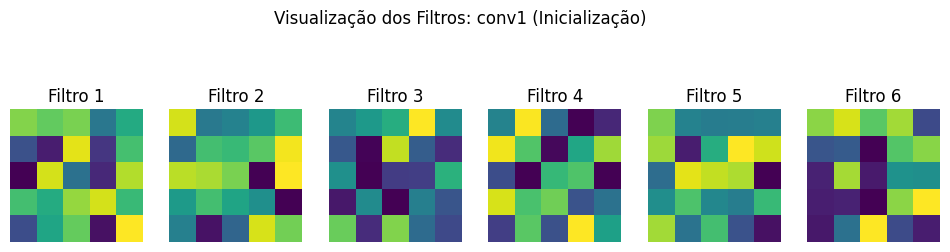


--- conv2: Resumo ---
Forma: torch.Size([16, 6, 5, 5])
Nota: Os filtros parecem ruído aleatório porque o treinamento ainda não refinou as características.


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_filters(layer, layer_name):
    """
    Extrai e plota os pesos de uma camada convolucional.
    Formato dos pesos: [filtros_saída, filtros_entrada, altura_kernel, largura_kernel]
    """
    weights = layer.weight.data.detach().cpu()
    num_filters = weights.shape[0]

    print(f"--- Analisando {layer_name} ---")
    print(f"Forma do Tensor: {weights.shape}")
    print(f"Estatísticas: Média={weights.mean():.4f}, Desvio={weights.std():.4f}, "
          f"Mín={weights.min():.4f}, Máx={weights.max():.4f}")

    fig, axes = plt.subplots(1, num_filters, figsize=(num_filters * 2, 3))
    for i in range(num_filters):
        kernel_img = weights[i, 0].numpy()
        ax = axes[i] if num_filters > 1 else axes
        ax.imshow(kernel_img, cmap="viridis")
        ax.axis("off")
        ax.set_title(f"Filtro {i+1}")
    plt.suptitle(f"Visualização dos Filtros: {layer_name} (Inicialização)", y=1.05)
    plt.show()

# Visualizar filtros da conv1
visualize_filters(model.conv1, "conv1")

# Informações da conv2 (16 filtros × 6 canais — difícil plotar em 2D)
print("\n--- conv2: Resumo ---")
print(f"Forma: {model.conv2.weight.data.shape}")
print("Nota: Os filtros parecem ruído aleatório porque o treinamento ainda não refinou as características.")


<h2 style="color:#2D6A4F;">📖 Dados de Entrada e Pré-processamento</h2>

<h3 style="color:#40916C;">O Dataset MNIST</h3>

O **MNIST** é um clássico conjunto de dados com 70.000 imagens em escala de cinza (28×28 pixels) de dígitos manuscritos (0–9). 
É dividido em 60.000 imagens de treino e 10.000 de teste.

<h3 style="color:#40916C;">Pré-processamento necessário</h3>

1. <b style="color:#40916C;">Padding</b>: A LeNet-5 clássica espera imagens 32×32. Adicionamos 2 pixels de borda em cada lado (28 + 4 = 32) com `transforms.Pad(2)`.
2. <b style="color:#40916C;">Conversão para Tensor</b>: `transforms.ToTensor()` converte a imagem PIL em um tensor PyTorch com valores entre 0 e 1.
3. <b style="color:#40916C;">Normalização</b>: `transforms.Normalize((0.1307,), (0.3081,))` padroniza os pixels usando a média e o desvio-padrão do MNIST, melhorando a convergência.

<h3 style="color:#40916C;">DataLoader e Batches</h3>

O `DataLoader` permite iterar sobre o dataset em **lotes (batches)** de tamanho fixo (ex: 64). 
Isso é fundamental para o treinamento via **mini-batch gradient descent** — atualiza os pesos a cada lote, não a cada imagem individual.


<h2 style="color:#2D6A4F;">📦 Carregando e Visualizando o MNIST</h2>


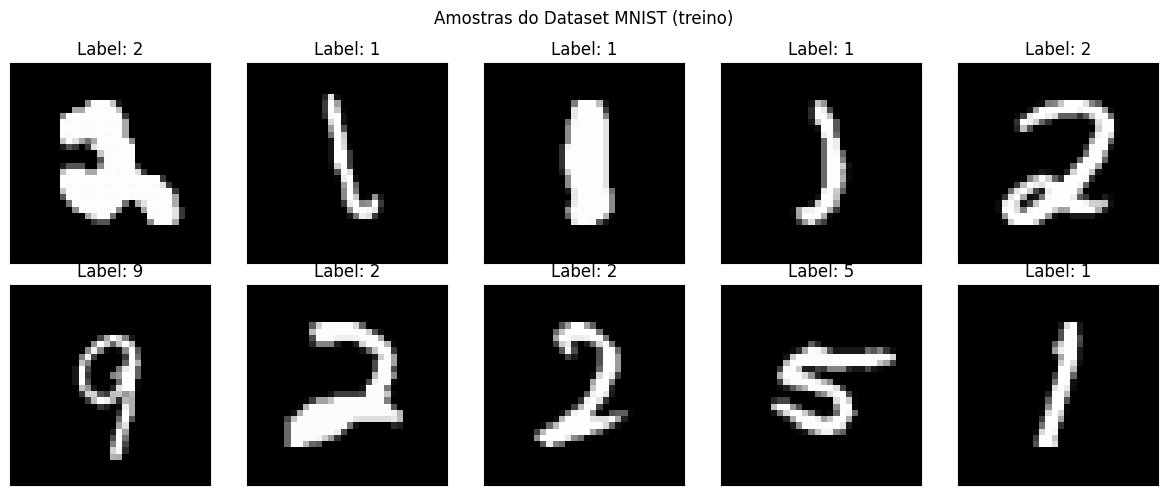

Dimensão do Batch: torch.Size([64, 1, 32, 32])
Dimensão de uma Imagem: torch.Size([1, 32, 32])


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Definição das Transformações
data_transform = transforms.Compose([
    transforms.Pad(padding=2),        # 28×28 → 32×32
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # Normalização padrão do MNIST
])

# 2. Download e carregamento dos datasets
train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=data_transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=data_transform)

# 3. Criação dos DataLoaders
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False)

# 4. Visualização de amostras
data_iterator = iter(train_loader)
images, labels = next(data_iterator)

fig = plt.figure(figsize=(12, 5))
num_images = 10
for i in range(num_images):
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
    img = images[i] * 0.3081 + 0.1307   # Desnormalizar para visualização
    np_img = img.numpy()
    plt.imshow(np.transpose(np_img, (1, 2, 0)), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
plt.suptitle("Amostras do Dataset MNIST (treino)")
plt.tight_layout()
plt.show()

print(f"Dimensão do Batch: {images.shape}")
print(f"Dimensão de uma Imagem: {images[0].shape}")


<h2 style="color:#2D6A4F;">📖 Camadas Totalmente Conectadas (FC) e o Flatten</h2>

Ao final do pipeline convolucional, realizamos um <b style="color:#40916C;">achatamento (Flatten)</b> dos mapas de características: 
o tensor 3D (filtros × altura × largura) é transformado em um **vetor 1D**, eliminando a estrutura espacial.

Esse vetor alimenta as camadas **Totalmente Conectadas** (`nn.Linear`), que funcionam como um <b style="color:#40916C;">Perceptron Multicamada</b> clássico. 
Elas combinam as representações abstratas dos filtros para calcular os **logits** — valores brutos que representam a "pontuação" de cada classe.

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #2D6A4F; margin:10px 0;">
🎯 Na nossa rede: 16 × 5 × 5 = <b>400</b> → 120 → 84 → <b>10</b> (uma saída por dígito).
</div>


<h2 style="color:#2D6A4F;">📖 O Loop de Treinamento — Como a Rede Aprende</h2>

O treinamento de uma CNN segue um ciclo repetitivo de quatro passos:

| Passo | Nome | Descrição |
|:---:|:---|:---|
| 1 | <b style="color:#40916C;">Forward Pass</b> | A imagem percorre as camadas da rede, produzindo os logits de saída. |
| 2 | <b style="color:#40916C;">Cálculo da Loss</b> | A `CrossEntropyLoss` compara os logits previstos com os rótulos verdadeiros e calcula o erro. |
| 3 | <b style="color:#40916C;">Backward Pass</b> | Os gradientes do erro são propagados de volta pela rede (backpropagation). |
| 4 | <b style="color:#40916C;">Atualização dos Pesos</b> | O otimizador (`Adam`) ajusta os pesos dos filtros na direção que minimiza o erro. |

<div style="padding:14px 18px; border-radius:8px; border-left:4px solid #2D6A4F; margin:10px 0;">
🔄 Este ciclo se repete para cada <b>batch</b> de imagens. Uma passagem completa pelo dataset inteiro é chamada de <b>época (epoch)</b>.
</div>


<h2 style="color:#2D6A4F;">🚀 Treinando a Rede Neural</h2>

Vamos configurar hiperparâmetros, definir a função de perda e o otimizador, e executar o loop de treinamento com validação ao fim de cada época.


In [5]:
import torch.optim as optim
import time

# 1. Dispositivo (GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinando no dispositivo: {device}")

# 2. Instanciar o modelo e mover para o dispositivo
model = LeNet5ReLU().to(device)

# 3. Hiperparâmetros
learning_rate = 0.001
num_epochs = 5

# Atualiza DataLoader de treino (caso batch_size tenha mudado)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# 4. Função de Perda e Otimizador
criterion = nn.CrossEntropyLoss()          # Combina LogSoftmax + NLLLoss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 5. Loop de Treinamento
train_losses = []

print("\nIniciando o treinamento...")
start_time = time.time()

for epoch in range(num_epochs):
    model.train()  # Modo treinamento
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # Zera gradientes acumulados
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels)  # Calcula a perda
        loss.backward()                 # Backward pass
        optimizer.step()                # Atualiza os pesos dos filtros

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Época [{epoch+1}/{num_epochs}]  Perda: {epoch_loss:.4f}")
elapsed = time.time() - start_time
print(f"\nTreinamento concluído em {elapsed:.2f} segundos.")

torch.save(model.state_dict(), "lenet5_mnist.pth")
print("Modelo salvo como 'lenet5_mnist.pth'")


Treinando no dispositivo: cpu

Iniciando o treinamento...
Época [1/5]  Perda: 0.2084
Época [2/5]  Perda: 0.0625
Época [3/5]  Perda: 0.0442
Época [4/5]  Perda: 0.0358
Época [5/5]  Perda: 0.0302

Treinamento concluído em 337.29 segundos.
Modelo salvo como 'lenet5_mnist.pth'


<h2 style="color:#2D6A4F;">📖 Avaliação do Desempenho</h2>

Após o treinamento, avaliamos a rede no **conjunto de teste** — dados que ela nunca viu durante o treino.

<h3 style="color:#40916C;">O que medir?</h3>

* <b style="color:#40916C;">Loss de teste</b>: quão distantes estão as previsões dos rótulos reais em média.
* <b style="color:#40916C;">Acurácia por classe</b>: permite identificar quais dígitos são mais difíceis para a rede.
* <b style="color:#40916C;">Acurácia geral</b>: porcentagem total de acertos sobre todo o conjunto de teste.


<h2 style="color:#2D6A4F;">📊 Avaliando o Modelo no Conjunto de Teste</h2>


In [ ]:
model.eval()

test_loss = 0.0
class_correct = [0.0] * 10
class_total   = [0.0] * 10

print("Iniciando avaliação no conjunto de teste...")

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct = np.squeeze(predicted.eq(target.data.view_as(predicted)))
        for i in range(len(target)):
            label = target.data[i]
            class_correct[label] += correct[i].item()
            class_total[label]   += 1

test_loss /= len(test_loader.dataset)
print(f"Perda no Teste: {test_loss:.6f}\n")

print("Acurácia por Dígito (0–9):")
for i in range(10):
    if class_total[i] > 0:
        print(f"  Dígito {i}: {100 * class_correct[i] / class_total[i]:.2f}%"
              f"  ({int(class_correct[i])}/{int(class_total[i])})")

overall = 100.0 * np.sum(class_correct) / np.sum(class_total)
print(f"\nAcurácia Geral: {overall:.2f}%")


<h2 style="color:#2D6A4F;">🖼️ Visualização das Predições</h2>

Vamos plotar imagens de teste com seus rótulos *previstos* e *reais*. 
Títulos em <b style="color:#40916C;">verde</b> = acerto; em <b style="color:#E74C3C;">vermelho</b> = erro.


In [ ]:
# Obter um batch de imagens de teste
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Predição
images_device = images.to(device)
output = model(images_device)
_, preds = torch.max(output, 1)

# Preparar para plotagem (voltar para CPU)
images_np = images.cpu().numpy()

fig = plt.figure(figsize=(25, 4))
num_show = 20

print("\nVisualização das Predições (Verde = Correto, Vermelho = Incorreto):")
for idx in range(num_show):
    ax = fig.add_subplot(2, num_show // 2, idx + 1, xticks=[], yticks=[])
    img_display = images_np[idx] * 0.3081 + 0.1307    # Desnormalizar
    plt.imshow(np.transpose(img_display, (1, 2, 0)), cmap="gray")
    pred_label = preds[idx].item()
    true_label = labels[idx].item()
    color = "green" if pred_label == true_label else "red"
    ax.set_title(f"Pred: {pred_label} (Real: {true_label})", color=color)
plt.tight_layout()
plt.show()


<h2 style="color:#2D6A4F;">❌ Análise dos Erros de Classificação</h2>

Para entender as fraquezas da rede, coletamos e visualizamos os erros — 
casos em que a predição difere do rótulo verdadeiro.


In [ ]:
# Coletar erros do conjunto de teste
wrong_images, wrong_preds, wrong_labels = [], [], []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, pred = torch.max(output, 1)
        wrong_mask = pred != target
        wrong_images.append(data[wrong_mask].cpu())
        wrong_preds.append(pred[wrong_mask].cpu())
        wrong_labels.append(target[wrong_mask].cpu())

wrong_images = torch.cat(wrong_images)
wrong_preds  = torch.cat(wrong_preds)
wrong_labels = torch.cat(wrong_labels)

num_errors = min(20, len(wrong_images))
print(f"Visualizando os primeiros {num_errors} erros encontrados:")

fig = plt.figure(figsize=(25, 8))
for idx in range(num_errors):
    ax = fig.add_subplot(4, 5, idx + 1, xticks=[], yticks=[])
    img = wrong_images[idx] * 0.3081 + 0.1307
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)), cmap="gray")
    ax.set_title(f"Pred: {wrong_preds[idx].item()} → Real: {wrong_labels[idx].item()}",
                 color="red", fontsize=9)
plt.suptitle("Imagens Classificadas Incorretamente", fontsize=14, color="red")
plt.tight_layout()
plt.show()
